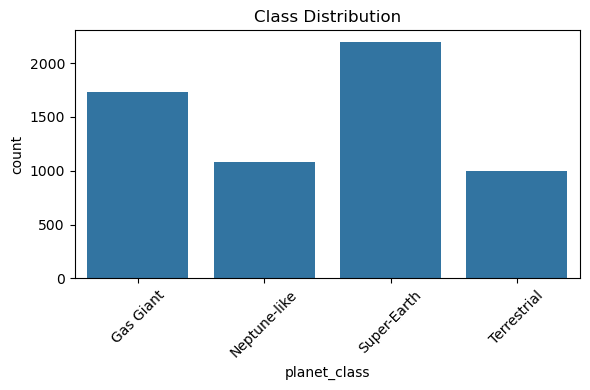


Class counts:
planet_class
Super-Earth     2195
Gas Giant       1734
Neptune-like    1079
Terrestrial      996
Name: count, dtype: int64

Class percentages (%):
planet_class
Super-Earth     36.56
Gas Giant       28.88
Neptune-like    17.97
Terrestrial     16.59
Name: proportion, dtype: float64

Final features used in Q1:
• pl_orbeccen
• pl_eqt
• st_logg
• sy_pnum
• log_pl_bmasse
• log_pl_orbper
• log_st_rad


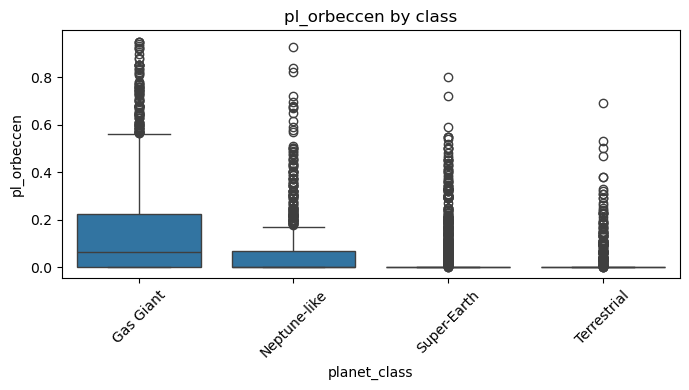

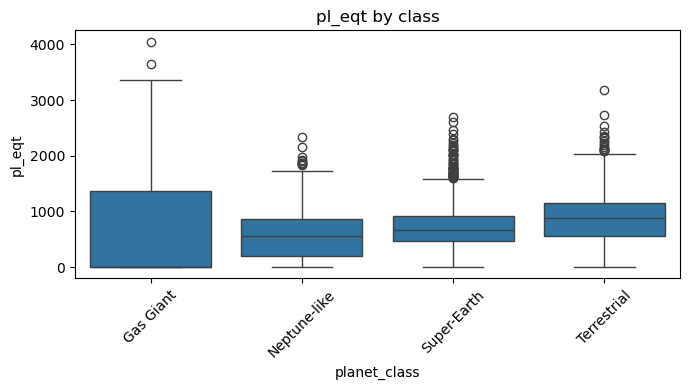

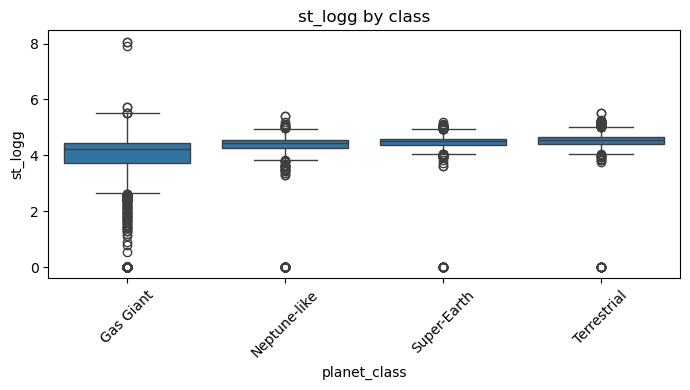

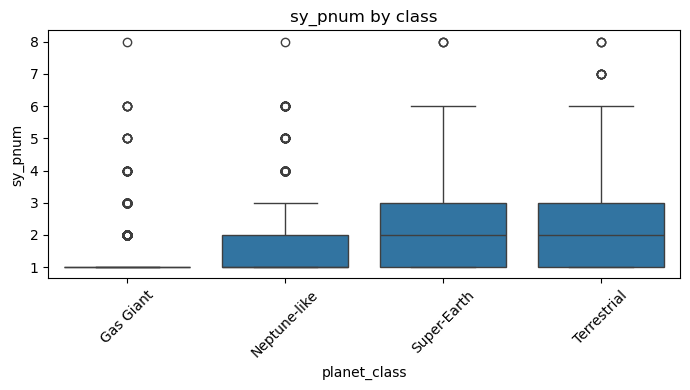

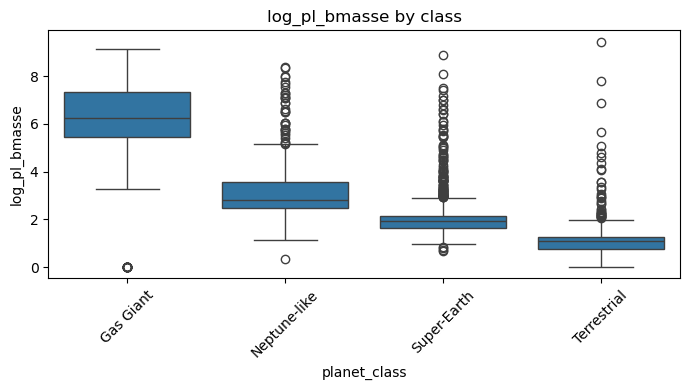

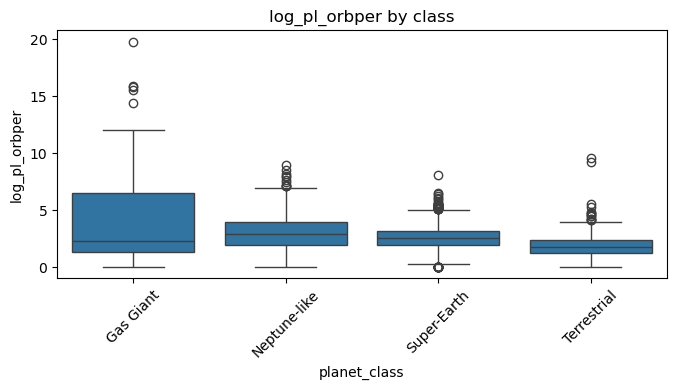

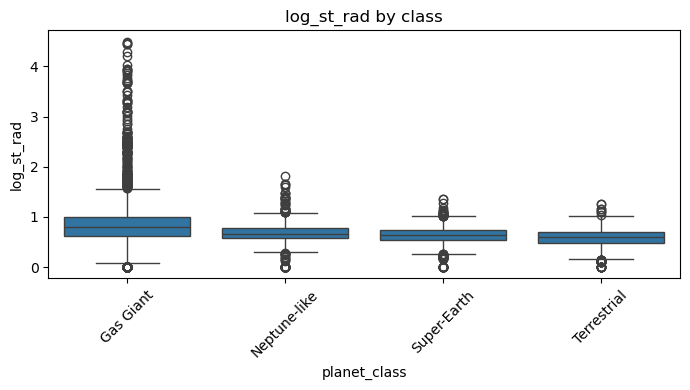

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 0. Duomenų užkrovimas
# =========================
df = pd.read_csv("exoplanet.csv")

# =========================
# 1. Klasės balansas
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="planet_class")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClass counts:")
print(df["planet_class"].value_counts())

print("\nClass percentages (%):")
print((df["planet_class"].value_counts(normalize=True) * 100).round(2))

# =========================
# 2. Požymių rinkinys Q1 analizei
# =========================

# be log transformacijos
features_raw = [
    "pl_orbeccen",
    "pl_eqt",
    "st_logg",
    "sy_pnum"
]

# su log transformacija
features_log = [
    "pl_bmasse",
    "pl_orbper",
    "st_rad"
]

df_q1 = df.copy()
for col in features_log:
    df_q1[f"log_{col}"] = np.log1p(df_q1[col].clip(lower=0))

# galutinis feature sąrašas heatmap/ui ir interpretacijai
final_features = features_raw + [f"log_{c}" for c in features_log]

print("\nFinal features used in Q1:")
for f in final_features:
    print("•", f)

# =========================
# 3. Boxplot'ai pagal klases
# =========================

# raw feature'iai
for col in features_raw:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_q1, x="planet_class", y=col)
    plt.title(f"{col} by class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# log-transformuoti feature'iai
for col in features_log:
    log_col = f"log_{col}"
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_q1, x="planet_class", y=log_col)
    plt.title(f"{log_col} by class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

